In [1]:
import os
import sys
from dotenv import find_dotenv
sys.path.append(os.path.dirname(find_dotenv()))
import glob
from pathlib import Path
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import matplotlib.transforms as transforms
import astropy.units as u
import astropy.constants as const
import arby
import tqdm
import dill as pickle
import dynesty
import dynesty.plotting as dyplot

import dill
import dynesty.utils
dynesty.utils.pickle_module = dill

import isidora.waveform
import isidora.plotting
import isidora.training

/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
plt.rc('font', family='serif')
plt.rc('xtick', labelsize='medium')
plt.rc('ytick', labelsize='medium')
# plt.rc('legend', fontsize=7.5)
plt.rc('legend', fontsize=10)
plt.rc('axes', titlesize='large')     # fontsize of the axes title
plt.rc('axes', labelsize='large')    # fontsize of the x and y labels
# plt.rc('text', usetex=True)
# plt.rc('axes', unicode_minus=False)
#matplotlib.rcParams['axes.unicode_minus'] = False

# Figure 1: parameter space

In [3]:
param_space_mesh_data = np.load('data/param_space_mesh.npz')

prev_param_space_lim_data = np.load('data/nofreqevo_limiting_Mc.npz')
meco_lim_data = np.load('data/meco_limiting_Mc.npz')

In [4]:
param_space_mesh_data

NpzFile 'data/param_space_mesh.npz' with keys: mesh_freq_hz, mesh_Mc_Msun, mesh_n_cycles, mesh_max_freq_in_obs_hz

In [5]:
relative_delta_f = (param_space_mesh_data['mesh_max_freq_in_obs_hz'] - param_space_mesh_data['mesh_freq_hz']) / param_space_mesh_data['mesh_freq_hz']

In [6]:
np.sum(relative_delta_f > 10**0.5) / relative_delta_f.size

np.float64(0.0008971028971028971)

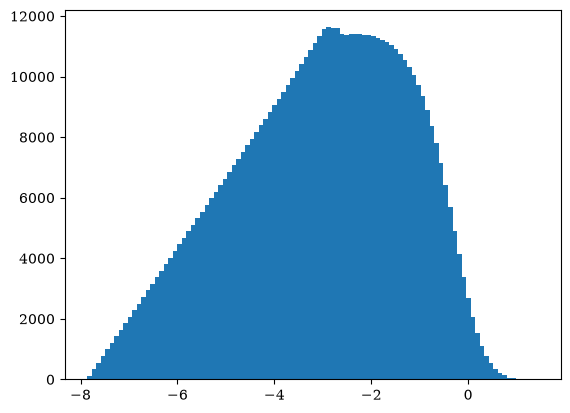

In [7]:
plt.hist(np.log10(relative_delta_f.flatten()), bins=100);

In [8]:
# Just cap it at log-10 = 0.5 then.
relative_delta_f[relative_delta_f > 10**0.5] = np.nan

In [9]:
def plot_param_space(axis, overlay_color='silver'):
    plt.sca(axis)
    # plt.pcolormesh(param_space_mesh_data['mesh_freq_hz'], param_space_mesh_data['mesh_Mc_Msun'], param_space_mesh_data['mesh_n_cycles'], norm=colors.LogNorm(), cmap='magma')
    # plt.colorbar(label=f'GW cycles in 3.5 yr observation period')
    plt.pcolormesh(param_space_mesh_data['mesh_freq_hz'], param_space_mesh_data['mesh_Mc_Msun'], relative_delta_f, norm=colors.LogNorm(), cmap='magma')
    plt.colorbar(label=r'$\Delta f / f_I$')
    
    plt.xlabel(r'$f_I$ [Hz]')
    plt.ylabel(r'$\mathcal{M}_c$ [$M_\odot$]')
    plt.xscale('log')
    plt.yscale('log')
    
    plt.plot(prev_param_space_lim_data['freq_hz'], prev_param_space_lim_data['limit_Mc'], color=overlay_color, ls='-', label='Zhang et al. 2025')
    hatch_data = prev_param_space_lim_data['limit_Mc']
    for i, d in enumerate(hatch_data):
        if d != np.inf:
            break
        hatch_data[i] = np.max(param_space_mesh_data['mesh_Mc_Msun'])
    hatch = plt.fill_between(prev_param_space_lim_data['freq_hz'], hatch_data, np.min(param_space_mesh_data['mesh_Mc_Msun']), hatch='/', hatchcolor=overlay_color, facecolor='none', edgecolor='none')
    
    meco_lim_mask = np.isfinite(meco_lim_data['limit_Mc'])
    
    meco_line_log_endpts = np.array([[meco_lim_data['freq_hz'][meco_lim_mask][0], meco_lim_data['freq_hz'][meco_lim_mask][-1]], 
                                     [meco_lim_data['limit_Mc'][meco_lim_mask][0], meco_lim_data['limit_Mc'][meco_lim_mask][-1]]])
    meco_line_log_endpts = np.log10(meco_line_log_endpts)
    text_angle = np.rad2deg(np.arctan2(meco_line_log_endpts[1][1] - meco_line_log_endpts[1][0], meco_line_log_endpts[0][1] - meco_line_log_endpts[0][0]))
    meco_line_log_midpoint = np.mean(meco_line_log_endpts, axis=1)
    print(meco_line_log_midpoint, text_angle)
    
    # plt.plot(*(10**meco_line_log_endpts), color='red')
    
    plt.plot(meco_lim_data['freq_hz'], meco_lim_data['limit_Mc'], color='xkcd:very dark brown', ls='-', lw=0.5)
    plt.text(*(10**meco_line_log_midpoint), 'MECO frequency cutoff\n\n', ha='center', va='center', rotation=text_angle + 2.7, rotation_mode='anchor', color='white')

[-6.16498358  8.49990185] -57.47959859549107


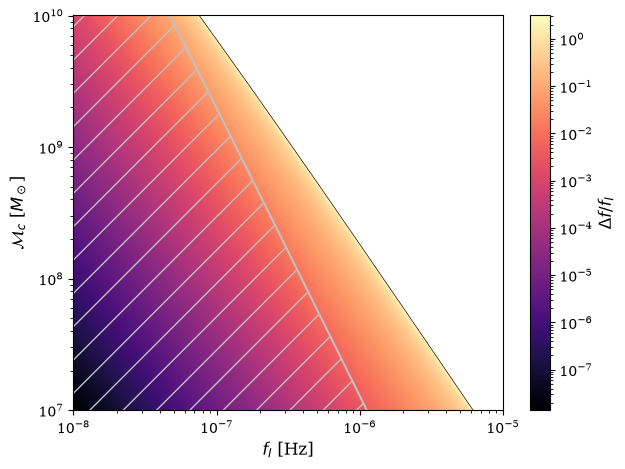

In [10]:
plot_param_space(plt.gca())
plt.tight_layout()
plt.savefig('figures/fig_1.png', dpi=300)

# Load RB data

In [11]:
with open('data/training_set_full_tile.pkl', 'rb') as f:
    full_tile = pickle.load(f)

with open('data/full_tile_rb.pkl', 'rb') as f:
    full_tile_rb = pickle.load(f)

with open('data/validation_set_full_tile.pkl', 'rb') as f:
    validation_tile = pickle.load(f)

In [12]:
total_rb_n_roq = isidora.training.n_roq_weights(full_tile_rb.basis.Nbasis_)
print(total_rb_n_roq)

3329490


# Determine best split strategy

In [13]:
STUDY_PATH = Path('data/maestro/pipeline-test-splits_20260625-160601')

total_roq_size_dict = {}
validation_err_dict = {}

for roq_size_dict_path in glob.glob(str(STUDY_PATH / '**' / 'roq_size_dict.pkl'), recursive=True):
    with open(roq_size_dict_path, 'rb') as f:
        roq_size_dict = pickle.load(f)
    total_roq_size_dict[(roq_size_dict['strategy'], roq_size_dict['n_output_tiles'], roq_size_dict['n_freq_overlap_oneside'], roq_size_dict_path)] = sum([v for k, v in roq_size_dict.items() if isinstance(k, tuple)])

    with open(Path(roq_size_dict_path).parent / 'validation_results.pkl', 'rb') as f:
        validation_res = pickle.load(f)
    validation_err_dict[(roq_size_dict['strategy'], roq_size_dict['n_output_tiles'], roq_size_dict['n_freq_overlap_oneside'], roq_size_dict_path)] = validation_res
    
total_roq_size_dict = {k: v for k, v in sorted(total_roq_size_dict.items(), key=lambda item: item[1])}

In [14]:
for i, (k, v) in enumerate(total_roq_size_dict.items()):
    print(f'ind {i} | strategy {k[0]}, n_output_tiles {k[1]}, n_freq_overlap_oneside {k[2]}: ROQ size {v}, relative savings {v / total_rb_n_roq:.2f}')

ind 0 | strategy minMc_freq, n_output_tiles 7, n_freq_overlap_oneside 2: ROQ size 1757621, relative savings 0.53
ind 1 | strategy minMc_freq, n_output_tiles 6, n_freq_overlap_oneside 2: ROQ size 1763729, relative savings 0.53
ind 2 | strategy minMc_freq, n_output_tiles 5, n_freq_overlap_oneside 2: ROQ size 1768500, relative savings 0.53
ind 3 | strategy minMc_freq, n_output_tiles 8, n_freq_overlap_oneside 2: ROQ size 1784050, relative savings 0.54
ind 4 | strategy minMc_freq, n_output_tiles 4, n_freq_overlap_oneside 2: ROQ size 1810506, relative savings 0.54
ind 5 | strategy minMc_freq, n_output_tiles 9, n_freq_overlap_oneside 2: ROQ size 1818206, relative savings 0.55
ind 6 | strategy minMc_freq, n_output_tiles 10, n_freq_overlap_oneside 2: ROQ size 1863016, relative savings 0.56
ind 7 | strategy minMc_freq, n_output_tiles 5, n_freq_overlap_oneside 8: ROQ size 1943605, relative savings 0.58
ind 8 | strategy minMc_freq, n_output_tiles 4, n_freq_overlap_oneside 8: ROQ size 1957657, rela

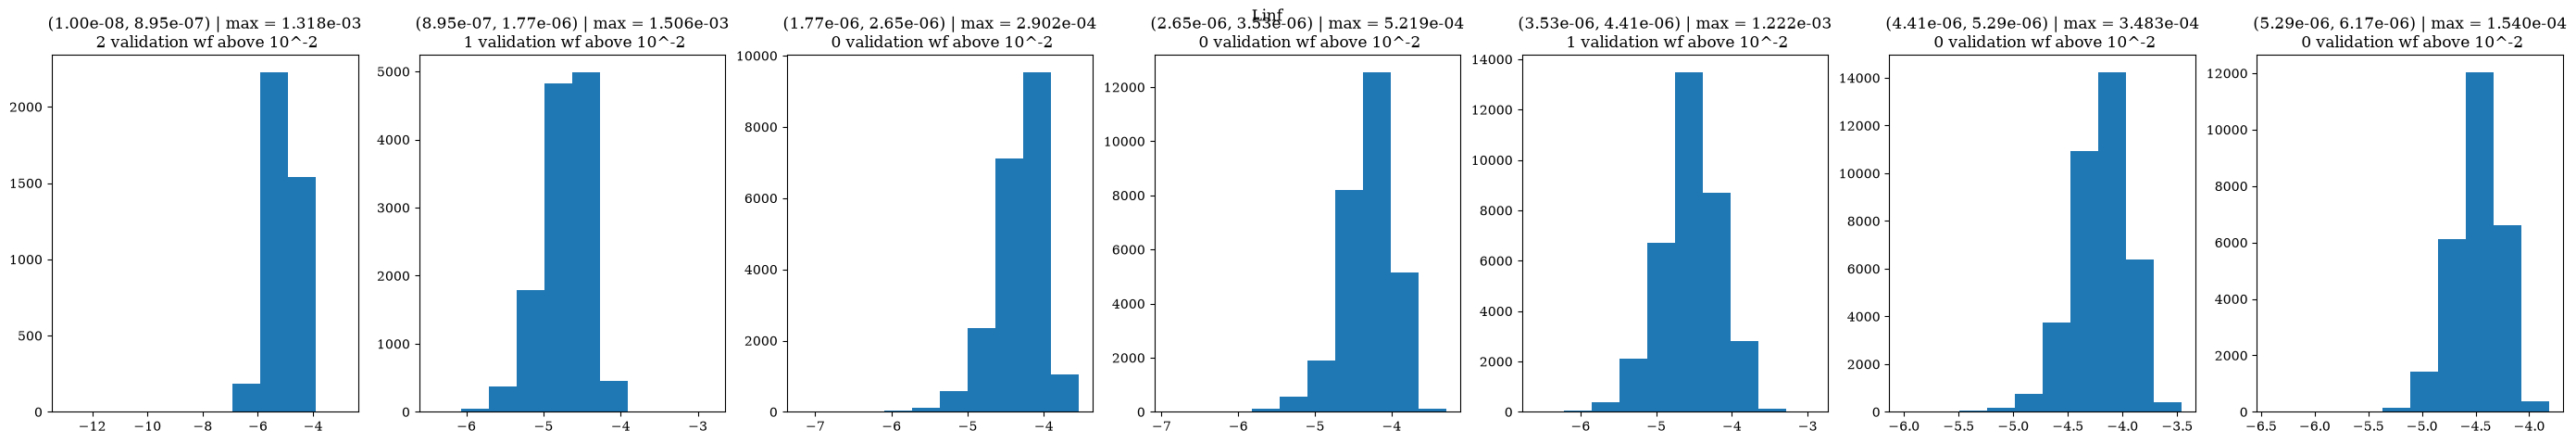

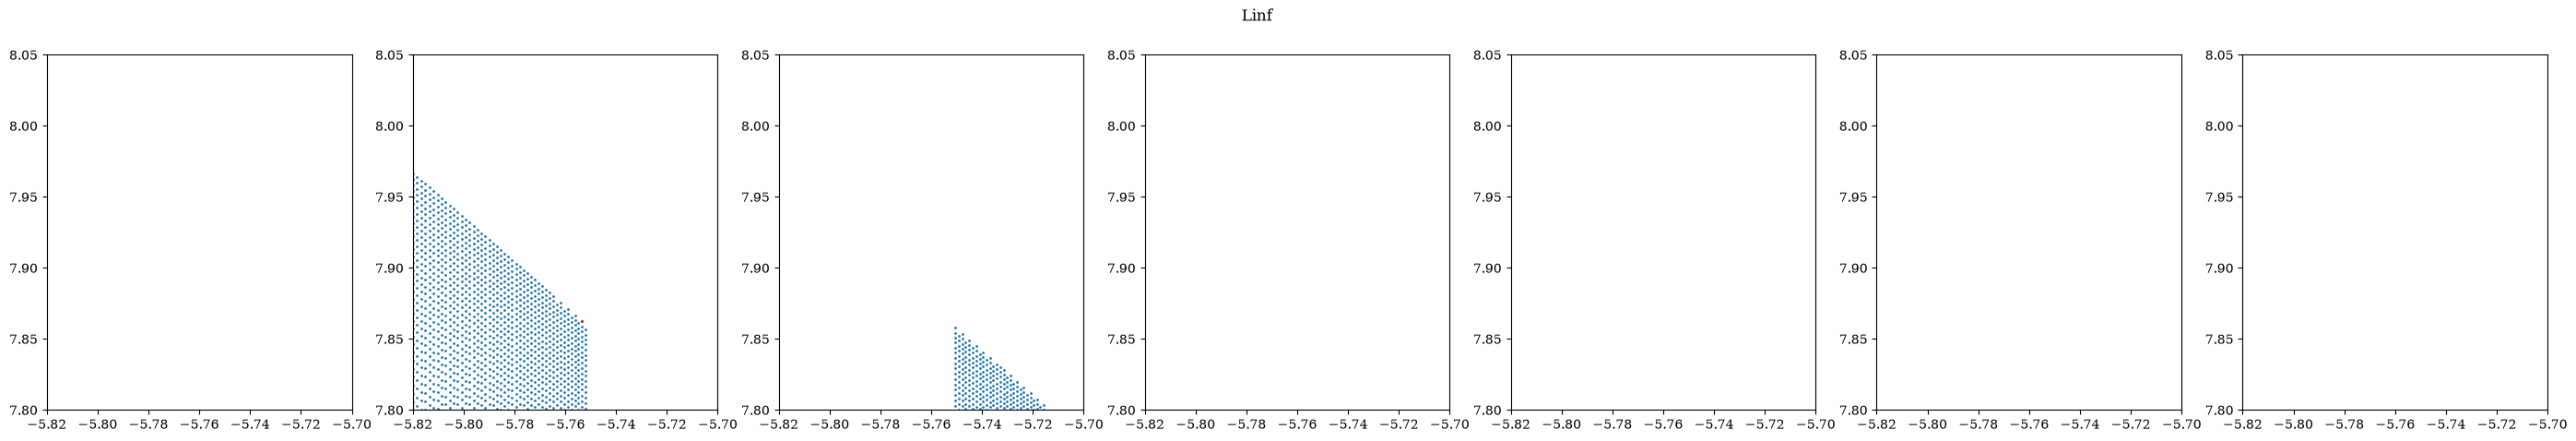

In [15]:
picked_key_ind = 0
validation_err_thres = 1e-3

validation_res = copy.deepcopy(validation_err_dict[list(total_roq_size_dict.keys())[picked_key_ind]])
wf_norm_choice = validation_res.pop('wf_norm')
fig, axes = plt.subplots(1, len(validation_res), figsize=(5 * len(validation_res), 5))

combined_validation_err = []

picked_roq_freq_lim = []

for ax, (freq_lim, validation_err) in zip(axes, validation_res.items()):
    validation_wf_inds = np.array(list(validation_err.keys()))
    verr = np.log10(np.array(list(validation_err.values())))
    ax.hist(verr)
    combined_validation_err.append(verr)
    picked_roq_freq_lim += freq_lim
    ax.set_title(f'({freq_lim[0].to(u.Hz).value:.2e}, {freq_lim[1].to(u.Hz).value:.2e}) | max = {10**np.max(verr):.3e}\n {np.sum(verr > np.log10(validation_err_thres))} validation wf above 10^-2')
fig.suptitle(wf_norm_choice)
plt.show()

fig, axes = plt.subplots(1, len(validation_res), figsize=(5 * len(validation_res), 5))
for ax, (freq_lim, validation_err) in zip(axes, validation_res.items()):
    validation_wf_inds = np.array(list(validation_err.keys()))
    verr = np.array(list(validation_err.values()))
    bad_wf_mask = verr > validation_err_thres
    freq = [validation_tile.tile_full_gw_param_list[i]['initial_freq'].to(u.Hz).value for i in validation_wf_inds]
    Mc = [validation_tile.tile_full_gw_param_list[i]['Mc'].to(u.Msun).value for i in validation_wf_inds]
    ax.scatter(np.log10(freq), np.log10(Mc), s=1)
    ax.scatter(np.log10(freq)[bad_wf_mask], np.log10(Mc)[bad_wf_mask], color='red', s=1)
    ax.set_xlim(-5.82, -5.7)
    ax.set_ylim(7.8, 8.05)
fig.suptitle(wf_norm_choice)
plt.show()

In [16]:
picked_roq_freq_lim = list(set(picked_roq_freq_lim))
picked_roq_freq_lim = sorted(picked_roq_freq_lim)
print(picked_roq_freq_lim)

# Get rid of first and last elems since those are implicit in param space bounds
del picked_roq_freq_lim[0]
del picked_roq_freq_lim[-1]

[<Quantity 1.e-08 Hz>, <Quantity 8.94535738e-07 Hz>, <Quantity 1.77336479e-06 Hz>, <Quantity 2.65219385e-06 Hz>, <Quantity 3.5310229e-06 Hz>, <Quantity 4.40985196e-06 Hz>, <Quantity 5.28868102e-06 Hz>, <Quantity 6.17321675e-06 Hz>]


In [17]:
np.mean(10**np.concatenate(combined_validation_err, axis=None))

np.float64(5.217194079147617e-05)

# Figure 2: reduced basis elements

In [18]:
# https://stackoverflow.com/questions/5558418/list-of-dicts-to-from-dict-of-lists
def listofdict_to_dictoflist(lod):
    return {k: [dic[k] for dic in lod] for k in lod[0]}

def plot_rb_elements(tile, tile_rb):
    expanded_training_params = [p | {'init_phi': 0} for p in tile.tile_full_gw_param_list]
    picked_params = [expanded_training_params[i] for i in tile_rb.indices]
    picked_params = listofdict_to_dictoflist(picked_params)
    
    freq = np.array([f.to(u.Hz).value for f in picked_params['initial_freq']])
    Mc = np.array([m.to(u.Msun).value for m in picked_params['Mc']])

    # fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    x_zoomin_lim = (1.5e-6, None)

    visible_y = Mc[np.logical_and(x_zoomin_lim[0] < freq, freq < np.max(freq))]
    y_zoomin_lim = (np.min(visible_y), np.max(visible_y))
    
    # plt.sca(axes[0])
    plt.scatter(freq, Mc, s=8, c='none', edgecolors='white', lw=1, zorder=10, label=f'Reduced basis: N = {len(Mc)}')
    # plt.xscale('log')
    # plt.yscale('log')
    # # plt.hexbin(x_data, y_data)
    # plt.xlabel(r'$f_I$ [Hz]')
    # plt.ylabel(r'$\mathcal{M}_c$ [$M_\odot$]')
    # # plt.gcf().suptitle(f'{tile_rb.basis.Nbasis_} basis elements')
    # plt.title(f'{tile_rb.basis.Nbasis_} reduced basis elements')

    # plt.sca(axes[1])
    # plt.scatter(freq, Mc, s=3, c='white', edgecolors='black')
    # plt.xlim(*x_zoomin_lim)
    # plt.ylim(*y_zoomin_lim)

In [19]:
# plot_rb_elements(full_tile, full_tile_rb)
# plt.xlim(None, 1e-5)
# plt.tight_layout()
# plt.savefig('figures/fig_2.pdf')

[-6.16498358  8.49990185] -57.47959859549107


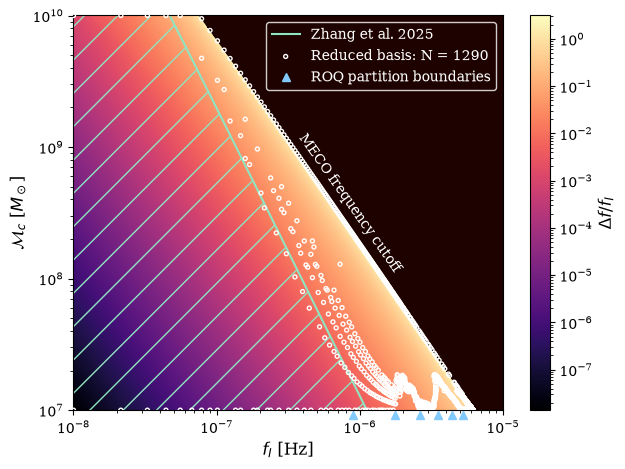

In [20]:
plot_param_space(plt.gca(), overlay_color='xkcd:light teal')
plot_rb_elements(full_tile, full_tile_rb)

# Plot ROQ partition boundaries
trans = transforms.blended_transform_factory(
    ax.transData,   # x is in data coordinates
    ax.transAxes,   # y is in axes coordinates
)

x_marks = [f.to(u.Hz).value for f in picked_roq_freq_lim]
plt.plot(
    x_marks,
    # [1.0135] * len(x_marks),
    [-0.0125] * len(x_marks),
    marker='^',
    linestyle='none',
    markersize=6,
    color='xkcd:sky',
    transform=plt.gca().get_xaxis_transform(),
    clip_on=False,
    label='ROQ partition boundaries',
)

# plt.gca().tick_params(axis='x', which='both', top=True, labeltop=False)
# plt.gca().tick_params(
#     axis='x',
#     which='major',
#     top=False,
#     bottom=True,
#     length=7.7,
# )

plt.gca().set_facecolor('xkcd:very dark brown')
# plt.gca().set_facecolor('xkcd:dark')
plt.legend(loc='upper right', labelcolor='white', frameon=True, facecolor='none', edgecolor='white')
plt.tight_layout()
plt.savefig('figures/fig_1_2_combined.png', dpi=600)

# Figure 3: Toy GW search results

In [21]:
with open('data/toy-mcmc/injected_wf_params.pkl', 'rb') as f:
    injected_wf_params = pickle.load(f)

true_mcmc_params = [np.log10(injected_wf_params['initial_freq'].to(u.Hz).value), np.log10(injected_wf_params['Mc'].to(u.Msun).value)]



In [22]:
exact_nested_samp = dynesty.NestedSampler.restore('data/toy-mcmc/exact-wf-ns.checkpt')
roq_nested_samp = dynesty.NestedSampler.restore('data/toy-mcmc/roq-wf-ns.checkpt')

In [23]:
zoomin_range=[(-5.9825, -5.980), (7.2, 7.7)]
corner_kwargs = dict(labels=[r'$f_I$ [Hz]', r'$\mathcal{M}_c$ [$M_\odot$]'], quantiles=None,
                     smooth=0.02, hist2d_kwargs=dict(no_fill_contours=True))
                     #range=zoomin_range, 
                     #plot_datapoints=False, plot_density=False, no_fill_contours=True)
hist_1d_kwargs = dict(histtype='stepfilled', alpha=0.5)

exact_run_color = 'royalblue'
roq_run_color = 'darkgoldenrod'

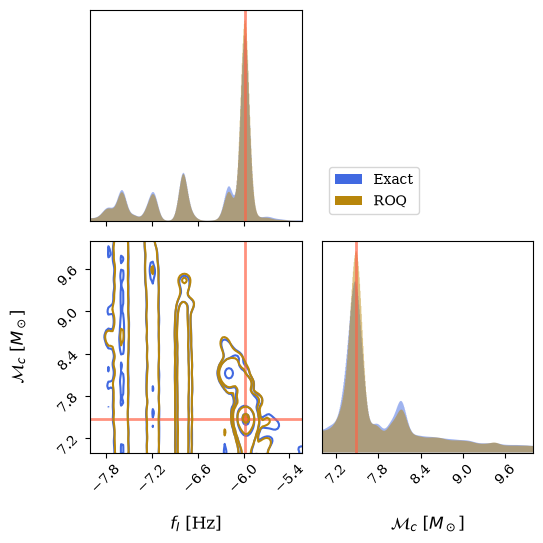

In [24]:
fig, ax = dynesty.plotting.cornerplot(exact_nested_samp.results, color=exact_run_color, hist_kwargs=hist_1d_kwargs, truths=true_mcmc_params, truth_color='tomato', **corner_kwargs)
dynesty.plotting.cornerplot(roq_nested_samp.results, fig=(fig, ax), color=roq_run_color, hist_kwargs=hist_1d_kwargs, **corner_kwargs)
ax[0, 1].legend(handles=[Patch(facecolor=exact_run_color, alpha=1, label='Exact'), Patch(facecolor=roq_run_color, alpha=1, label='ROQ')], loc='lower left')
# for fac in [2, 4, 8, 16, 32, 64]:
#     ax[0, 0].axvline(true_mcmc_params[0] - np.log10(fac), color='black')
# plt.gcf().suptitle(f'Exact | ln-evidence {exact_nested_samp.results.logz[-1]:.2f}')
plt.tight_layout()
# plt.savefig('figures/fig_3a.pdf')

In [25]:
roq_log_l = np.load('data/toy-mcmc/roq-log-l-at-exact-samples.npy')
exact_log_l = exact_nested_samp.results.logl

# # Resample both according to their evidence weights.
# resampled_exact = exact_nested_samp.results.samples_equal(rstate=np.random.default_rng(327472387))

# new_exact_log_l = []
# new_roq_log_l = []
# for resamp in resampled_exact:
#     ind = np.argwhere(resamp == exact_nested_samp.results.samples)[0, 0]
#     new_exact_log_l.append(exact_log_l[ind])
#     new_roq_log_l.append(roq_log_l[ind])

# roq_log_l = new_roq_log_l
# exact_log_l = new_exact_log_l

9


Text(0, 0.5, 'Nested sampling iteration count')

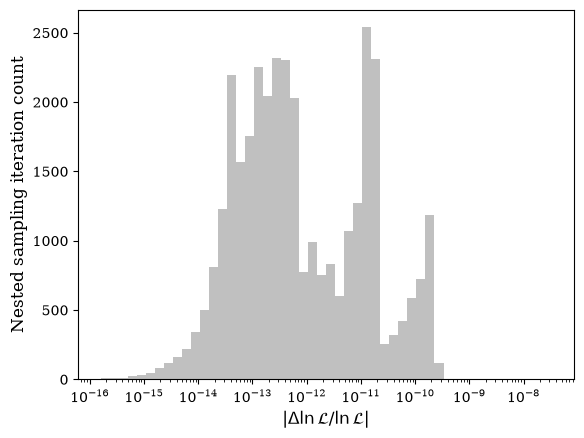

In [26]:
fractional_ln_L_err = np.abs((roq_log_l - exact_log_l) / exact_log_l)
print(np.sum(fractional_ln_L_err == 0))
fractional_ln_L_err = fractional_ln_L_err[fractional_ln_L_err != 0]

# https://stackoverflow.com/a/54529366
def make_logscale_bins(x, bins):
  hist, bins = np.histogram(x, bins=bins)
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
  return logbins

logbins = make_logscale_bins(fractional_ln_L_err, 50)

# l_of_split_mask = exact_nested_samp.results.samples[:, 0] < true_mcmc_params[0]
plt.hist(fractional_ln_L_err, bins=logbins, stacked=True, color='silver')
# plt.hist([fractional_ln_L_err[l_of_split_mask], fractional_ln_L_err[~l_of_split_mask]], bins=logbins, stacked=True, label=['Left of ROQ partition', 'Right of ROQ partition'])
# plt.legend()

plt.xscale('log')
plt.xlabel(r'$|\Delta \ln \mathcal{L} / \ln \mathcal{L}|$')
plt.ylabel('Nested sampling iteration count')

# plt.tight_layout()
# plt.savefig('figures/fig_3b.pdf')

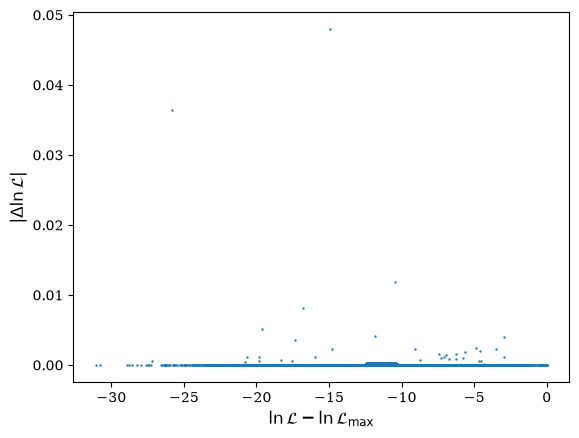

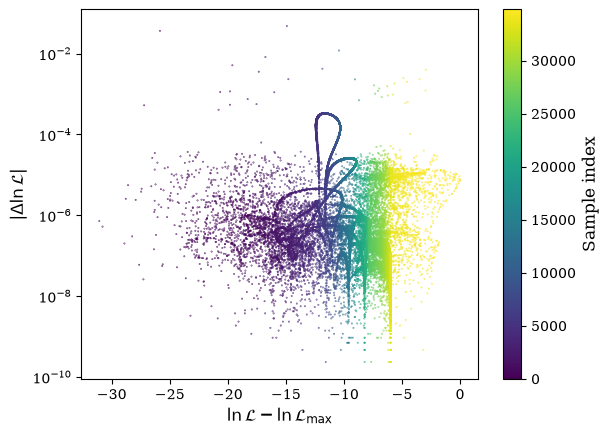

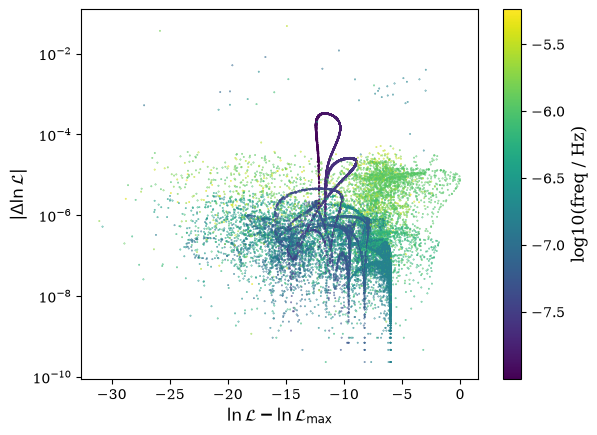

In [27]:
exact_lnL_minus_max = exact_log_l - np.max(exact_log_l)
abs_lnL_err = np.abs(roq_log_l - exact_log_l)

nonzero_mask = abs_lnL_err != 0

plt.scatter(exact_lnL_minus_max, abs_lnL_err, s=0.5)
plt.ylabel(r'$|\Delta \ln \mathcal{L}|$')
plt.xlabel(r'$\ln \mathcal{L} - \ln \mathcal{L}_\text{max}$')
plt.show()

plt.scatter(exact_lnL_minus_max[nonzero_mask], abs_lnL_err[nonzero_mask], s=0.1, c=np.arange(0, np.sum(nonzero_mask)))
plt.yscale('log')
plt.ylabel(r'$|\Delta \ln \mathcal{L}|$')
plt.xlabel(r'$\ln \mathcal{L} - \ln \mathcal{L}_\text{max}$')
plt.colorbar(label='Sample index')
plt.show()

plt.scatter(exact_lnL_minus_max[nonzero_mask], abs_lnL_err[nonzero_mask], s=0.1, c=exact_nested_samp.results.samples[nonzero_mask, 0])
plt.yscale('log')
plt.ylabel(r'$|\Delta \ln \mathcal{L}|$')
plt.xlabel(r'$\ln \mathcal{L} - \ln \mathcal{L}_\text{max}$')
plt.colorbar(label='log10(freq / Hz)')

33.0 outliers above largest visible bin
Smallest lnL - lnL_max of an outlier is -2.9482906134799123


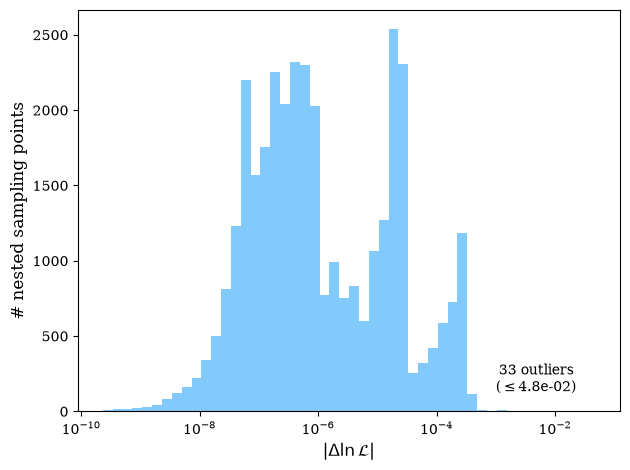

In [28]:
def make_logscale_bins(x, bins):
  hist, bins = np.histogram(x, bins=bins)
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
  return logbins

filtered_abs_lnL_err = abs_lnL_err[abs_lnL_err != 0]

bin_n, edges, _ = plt.hist(filtered_abs_lnL_err, bins=make_logscale_bins(filtered_abs_lnL_err, 50), color='xkcd:sky');
bin_centers = 0.5 * (edges[:-1] + edges[1:])

plt.xscale('log')
plt.xlabel(r'$|\Delta \ln \mathcal{L}|$')
plt.ylabel('# nested sampling points')

outlier_start = None
n_upper_outliers = 0
for i, n in enumerate(bin_n):
    if n < 100 and bin_centers[i] > 1e-4:
        if outlier_start is None:
            outlier_start = edges[i]
        n_upper_outliers += n

print(f'{n_upper_outliers} outliers above largest visible bin')
# plt.axvspan(outlier_start, filtered_abs_lnL_err.max(), alpha=0.2, color='gray')
_, _, ymin, ymax = plt.axis()
# plt.text(10**((np.log10(outlier_start) + np.log10(filtered_abs_lnL_err.max())) / 2), (ymin + ymax) / 2, f'{int(n_upper_outliers)} outliers\n($\leq${filtered_abs_lnL_err.max():.1e})',
#         horizontalalignment='center', verticalalignment='center')
plt.text(10**((np.log10(outlier_start) + np.log10(filtered_abs_lnL_err.max())) / 2), 100, f'{int(n_upper_outliers)} outliers\n($\leq${filtered_abs_lnL_err.max():.1e})',
        horizontalalignment='center', verticalalignment='bottom')

print(f'Smallest lnL - lnL_max of an outlier is {np.max(exact_lnL_minus_max[abs_lnL_err > outlier_start])}')

plt.tight_layout()
plt.savefig('figures/fig_3b.pdf')

In [29]:
print(f'{outlier_start:.2e}')

4.85e-04


In [30]:
bin_centers

array([2.87138157e-10, 4.21087529e-10, 6.17524014e-10, 9.05597724e-10,
       1.32805724e-09, 1.94759327e-09, 2.85614161e-09, 4.18852592e-09,
       6.14246483e-09, 9.00791231e-09, 1.32100853e-08, 1.93725635e-08,
       2.84098253e-08, 4.16629517e-08, 6.10986347e-08, 8.96010249e-08,
       1.31399723e-07, 1.92697429e-07, 2.82590391e-07, 4.14418240e-07,
       6.07743515e-07, 8.91254642e-07, 1.30702314e-06, 1.91674680e-06,
       2.81090533e-06, 4.12218700e-06, 6.04517894e-06, 8.86524275e-06,
       1.30008607e-05, 1.90657360e-05, 2.79598634e-05, 4.10030835e-05,
       6.01309394e-05, 8.81819015e-05, 1.29318581e-04, 1.89645439e-04,
       2.78114654e-04, 4.07854581e-04, 5.98117922e-04, 8.77138729e-04,
       1.28632218e-03, 1.88638889e-03, 2.76638551e-03, 4.05689878e-03,
       5.94943390e-03, 8.72483283e-03, 1.27949498e-02, 1.87637681e-02,
       2.75170282e-02, 4.03536664e-02])

In [31]:
abs_lnL_err.max()

np.float64(0.04798590624704957)

In [32]:
abs_lnL_err.min()

np.float64(0.0)